In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from pmdarima import auto_arima
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingRegressor
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.seasonal import seasonal_decompose

import warnings
warnings.filterwarnings("ignore")


### 364 days T-Bills data --> Path to download the data 

rbi.org.in --> statistics --> database on indian economy --> publication -->
handbook of statistics on indian economy --> series with less than monthly frequency --> list of reports --> Auction of 364 days govt of india treasury bill


In [2]:
import glob
import os
 
path="D:\\TASK\\CP rates\\TBILL-364"
 
files = glob.glob(path + "/*.xlsx")
 
df = pd.DataFrame()
content = []
for filename in files:
    print(filename)
    # reading content of csv file
    # content.append(filename)
    data = pd.read_excel(filename)
    content.append(data)
# converting content to data frame
df = pd.concat(content)

D:\TASK\CP rates\TBILL-364\Auctions of 364-Day Government of India Treasury Bills.xlsx


In [3]:
## This function is used to remove the unwanted headers in the T-bill excel sheet and extract data
def Data_Preprocessing(a):

    b=a.iloc[8:800,1:14]
    print(b.head())

    b.columns=['Auction Date','Date of Issue','Notified Amount','Bids Received-Number','Bids Received-Total Face Value-Competitive','Bids Received-Total Face Value-Non-Competitive','Bids Accepted-Number','Bids Accepted-Total Face Value-Competitive','Bids Accepted-Total Face Value-Non-Competitive','Devolvement on PDs/SDs','Total Issue (8+9+10)','Cut-off Price','Cut-off Yield']

    c=b[b['Date of Issue'].isnull()==False][['Auction Date','Cut-off Price','Cut-off Yield']]

    df1=c.dropna(subset='Auction Date')
    a=df1.drop_duplicates()
    a.loc[a['Cut-off Yield']=="-",'Cut-off Yield']=np.nan
    a.loc[a['Cut-off Price']=="-",'Cut-off Price']=np.nan
    return a

datas=Data_Preprocessing(df)

             Unnamed: 1           Unnamed: 2 Unnamed: 3 Unnamed: 4 Unnamed: 5  \
8            2025-26                     NaN        NaN        NaN        NaN   
9   2025-12-24 00:00:00  2025-12-26 00:00:00       6000         67    14695.2   
10  2025-12-17 00:00:00  2025-12-18 00:00:00       6000         91      15600   
11  2025-12-10 00:00:00  2025-12-11 00:00:00       6000        100      16425   
12  2025-12-03 00:00:00  2025-12-04 00:00:00       6000        121      21691   

   Unnamed: 6 Unnamed: 7 Unnamed: 8 Unnamed: 9 Unnamed: 10 Unnamed: 11  \
8         NaN        NaN        NaN        NaN         NaN         NaN   
9     244.317         46   5755.683    244.317           -        6000   
10   1683.622         47       5700       1570           -        7270   
11    1628.71         47    5971.29    1628.71           -        7600   
12    985.486         52   5814.514    985.486           -        6800   

   Unnamed: 12 Unnamed: 13  
8          NaN         NaN  
9      94.

In [4]:
def Additional_Data_Ingestion_Sorting(a):
    # If we want to add the cut-off yield manually for particular date we can insert in below Dates, yields and price array
    Dates=[]
    yields=[]
    prices=[]
    temp=pd.DataFrame({"Auction Date":Dates,"Cut-off Price":prices,"Cut-off Yield":yields})
    a=pd.concat([a,temp],axis=0)
    a['Auction Date']=pd.to_datetime(a['Auction Date'])
    a=a.sort_values(by='Auction Date',ascending=True)
    a.loc[a['Cut-off Price']=="-",'Cut-off Price']=np.nan
    a.loc[a['Cut-off Yield']=="-",'Cut-off Yield']=np.nan
    a=a.drop_duplicates()
    a=a.reset_index(drop=True)
    print(a.shape)
    return a

datas= Additional_Data_Ingestion_Sorting(datas)

(769, 3)


In [5]:
## Filtering the data from Jan-2010
def Data_subset(a):
    a1=a[a['Auction Date']>="2010-01-13"]
    print(a1.shape)
    return a1

datas=Data_subset(datas)

(629, 3)


In [6]:
# This function is to do the data cleaning and forward fill values in between weeks where values are null
def Equal_frequency_making(a1):
    a1=a1.set_index('Auction Date')
    a2=a1.resample('D').ffill()
    data_index = pd.date_range(start='2010-01-13', end=a2.index.max(), freq='W-WED') # 756 is the length from
    a3=pd.DataFrame({"Auction Date":data_index})
    a_1=pd.merge(left=a3,right=a2,on="Auction Date",how='left')
    a_1=a_1.set_index('Auction Date')
    a_1['Cut-off Yield']=a_1['Cut-off Yield'].fillna(method='ffill')  # Forward fill
    a_1['Cut-off Price']=a_1['Cut-off Price'].fillna(method='ffill')  # Forward fill
    a_1['Month'] = a_1.index.month.astype(str)  # Create a new column for month as strings
    return a_1

datas=Equal_frequency_making(datas)

In [7]:
datas.index.name='Date'
datas=datas.drop('Month',axis=1)
datas.head(3)

,Cut-off Price,Cut-off Yield
Date,,
2010-01-13,95.55,4.67
2010-01-20,95.55,4.67
2010-01-27,95.55,4.67


In [8]:
datas.tail(3)

,Cut-off Price,Cut-off Yield
Date,,
2025-12-10,94.8048,5.4949
2025-12-17,94.7963,5.5044
2025-12-24,94.7656,5.5387


In [ ]:
## Uncommand this line if you want to insert the one or two data's manually in dataframe instead of loading the T-bills excel

# datas.loc[datas.index[-2], 'Cut-off Yield'] = 6.5638
# datas.loc[datas.index[-1], 'Cut-off Yield'] = 6.5409
# datas.tail()

### US- Federal Reserve Rate

In [9]:

import requests
from bs4 import BeautifulSoup

def fetch_fomc_table_bs4(url: str):
    headers = {
        "User-Agent": (
            "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
            "AppleWebKit/537.36 (KHTML, like Gecko) "
            "Chrome/120.0.0.0 Safari/537.36"
        ),
        "Accept-Language": "en-US,en;q=0.9",
        "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8",
    }

    with requests.Session() as s:
        s.headers.update(headers)
        try:
            resp = s.get(url, timeout=15)
            resp.raise_for_status()  # raises HTTPError for 4xx/5xx
        except requests.exceptions.RequestException as e:
            raise RuntimeError(f"Network/HTTP error fetching page: {e}")

        soup = BeautifulSoup(resp.content, "html.parser")

        # Some Wikipedia pages have multiple 'wikitable sortable' tables.
        tables = soup.find_all("table", class_="wikitable sortable")
        if not tables:
            # try plain 'wikitable'
            tables = soup.find_all("table", class_="wikitable")
        if not tables:
            raise RuntimeError("No 'wikitable' found on the page.")

        # pick the first table; adapt if you need a specific one
        table = tables[0]

        # Extract headers (optional but helpful)
        header_cells = table.find_all("tr")[0].find_all(["th", "td"])
        headers = [hc.get_text(strip=True) for hc in header_cells]

        data = []
        for tr in table.find_all("tr")[1:]:  # skip header row
            tds = tr.find_all("td")
            if not tds:
                continue
            row = [td.get_text(strip=True) for td in tds]
            # skip empty rows
            if any(cell for cell in row):
                data.append(row)

        return headers, data


if __name__ == "__main__":
    url = "https://en.wikipedia.org/wiki/History_of_Federal_Open_Market_Committee_actions"
    try:
        headers, data = fetch_fomc_table_bs4(url)
        print("Columns:", headers)
        print(f"Rows extracted: {len(data)}")
        # Example: print first 5 rows
        for r in data[:5]:
            print(r)
    except Exception as e:
        print(f"Error: {e}")


Columns: ['Date', 'Fed. Funds Rate', 'Discount Rate', 'Votes', 'Notes']
Rows extracted: 143
['December 10, 2025', '3.50%–3.75%', '3.75%', '9–3', 'Stephen Miranpreferred a higher 50-basis-point cut, whileAustan GoolsbeeandJeffrey Schmidpreferred to maintain the rate.Official statement']
['October 29, 2025', '3.75%–4.00%', '4.00%', '10–2', 'Stephen Miranpreferred a higher 50-basis-point cut, whileJeffrey Schmidpreferred to maintain the rate.Official statement']
['September 17, 2025', '4.00%–4.25%', '4.25%', '11–1', 'Stephen Miranpreferred a higher 50-basis-point cut.Official statement']
['July 30, 2025', '4.25%–4.50%', '4.50%', '9–2', 'Michelle BowmanandChristopher Wallerpreferred a 25-basis-point cut.Official statement']
['June 18, 2025', '4.25%–4.50%', '4.50%', '12–0', 'Official statement']


In [10]:

import re
import pandas as pd
import numpy as np

# Assuming these variables are already defined from your working scraping function:
# headers, data = fetch_fomc_table_bs4(url)

# Build the DataFrame with your desired column names
fed = pd.DataFrame(
    data,
    columns=['Date', 'Fed_Funds_Rate', 'Fed_Reserve_Rate', 'Votes', 'Notes']
)

# Keep only Date and Fed_Reserve_Rate
fed = fed[['Date', 'Fed_Reserve_Rate']].copy()

# Reset index
fed = fed.reset_index(drop=True)

# Convert Date to datetime (coerce invalid formats to NaT)
fed['Date'] = pd.to_datetime(fed['Date'], errors='coerce')

# Clean Fed_Reserve_Rate text:
# 1) Remove footnote brackets like [a], [1], etc.
# 2) Normalize unicode en dashes to hyphens for splitting ranges
# 3) Remove '%' symbols and extra spaces
def clean_rate_text(x: str) -> str:
    if pd.isna(x):
        return x
    x = re.sub(r'\[.*?\]', '', x)         # remove bracketed notes
    x = x.replace('–', '-')               # en dash to hyphen
    x = x.replace('−', '-')               # minus sign to hyphen (just in case)
    x = x.replace('%', '')                # remove percent sign
    return x.strip()

fed['Fed_Reserve_Rate'] = fed['Fed_Reserve_Rate'].astype(str).apply(clean_rate_text)

# Convert to float:
# - If it's a range like "5.25-5.50", take the midpoint.
# - If it's a single number like "5.50", parse directly.
# - If unparsable (e.g., "N/A"), return NaN.
def parse_rate_to_float(x: str) -> float:
    if x is None or x == '' or x.lower() in {'na', 'n/a', 'nan'}:
        return np.nan
    # Range detection (two numbers separated by '-')
    if '-' in x:
        parts = [p.strip() for p in x.split('-') if p.strip() != '']
        try:
            nums = [float(p) for p in parts]
            if len(nums) == 2:
                return (nums[0] + nums[1]) / 2.0
            # If more than two parts, fallback to first parsable
            return float(nums[0]) if nums else np.nan
        except ValueError:
            return np.nan
    # Single value
    try:
        return float(x)
    except ValueError:
        return np.nan

fed['Fed_Reserve_Rate'] = fed['Fed_Reserve_Rate'].apply(parse_rate_to_float).astype('float64')

# Show the first few rows
print(fed.head())


        Date  Fed_Reserve_Rate
0 2025-12-10              3.75
1 2025-10-29              4.00
2 2025-09-17              4.25
3 2025-07-30              4.50
4 2025-06-18              4.50


In [ ]:
# '''Load this cell if you can't web scrap the fed reserve data from the wikipedia. 
# you have to collect the fed data manually from below webiste in excel load this cell.
# https://en.wikipedia.org/wiki/History_of_Federal_Open_Market_Committee_actions'''

# fed= pd.read_excel(r"D:\TASK\CP rates\Cogencis data\US Fed Reserve rate.xlsx")
# fed=fed[['Date','Discount Rate']]
# fed['Discount Rate']= fed['Discount Rate']*100
# fed=fed.reset_index(drop=True)
# fed['Date']=pd.to_datetime(fed['Date'])
# #fed['Discount Rate']= fed['Discount Rate'].str.replace("%","")
# #fed['Discount Rate']= fed['Discount Rate'].apply(lambda x: re.sub(r'\[.*?\]', '', x))
# fed['Discount Rate']= fed['Discount Rate'].astype('float64')
# fed.rename(columns={'Discount Rate':'Fed_Reserve_Rate'}, inplace=True)
# fed.head()

In [11]:
# This cell is to convert the fed reserve data to daily format

fed= fed.sort_values('Date', ascending=True)
fed= fed.set_index('Date')
fed_daily= fed.resample('D').ffill()
fed_daily.tail()

,Fed_Reserve_Rate
Date,
2025-12-06,4.00
2025-12-07,4.00
2025-12-08,4.00
2025-12-09,4.00
2025-12-10,3.75


In [12]:
# In this cell appending the fed data into base dataframe (cut-off yield)

base= pd.merge(datas, fed_daily, left_index=True, right_index=True, how='left')
base= base.ffill()
print(base.shape)
base.head(3)

(833, 3)


,Cut-off Price,Cut-off Yield,Fed_Reserve_Rate
Date,,,
2010-01-13,95.55,4.67,0.5
2010-01-20,95.55,4.67,0.5
2010-01-27,95.55,4.67,0.5


In [13]:
base.tail(3)

,Cut-off Price,Cut-off Yield,Fed_Reserve_Rate
Date,,,
2025-12-10,94.8048,5.4949,3.75
2025-12-17,94.7963,5.5044,3.75
2025-12-24,94.7656,5.5387,3.75


### Monetory Rates- Bank rates, MSF & SDF

#### Path to get the data from RBI website

Home > Publication --> Handbook of Statistics on the Indian Economy --> Part I: Annual series --> Money and Banking -->
Major Monetary Policy Rates and Reserve Requirements - Bank Rate, LAF (Repo, Reverse Repo and MSF) Rates, CRR & SLR

In [14]:
monetory= pd.read_excel(r"D:\TASK\CP rates\Cogencis data\Major Monetary Policy Rates.xlsx")
monetry=monetory.iloc[7:150,1:]
monetry.rename(columns={'Unnamed: 1':'Date', 'Unnamed: 2':'Bank Rate', 'Unnamed: 3':'Repo',
                        'Unnamed: 4':'Reverse Repo', 'Unnamed: 5':'Standing Deposit Facility Rate', 
                        'Unnamed: 6':'Marginal Standing Facility Rate', 'Unnamed: 7':'Cash Reserve Ratio',
                        'Unnamed: 8':'Statutory Liquidity Ratio'}, inplace=True)

monetory.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8
0,NaN,Major Monetary Policy Rates and Reserve Requir...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,(Per cent),NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,Effective Date\n,Bank Rate,Fix Range LAF Rates,NaN,Standing Deposit Facility (SDF) Rate,Marginal Standing Facility (MSF) Rate,Cash Reserve Ratio (CRR),Statutory Liquidity Ratio (SLR)


In [15]:
# In this cell done the sorting and filling the null values in df with previous values

monetry= monetry.sort_values(by='Date',ascending=True)
monetry= monetry.replace('-',np.nan)
monetry= monetry.ffill()
monetry= monetry.bfill()
monetry.head()

,Date,Bank Rate,Repo,Reverse Repo,Standing Deposit Facility Rate,Marginal Standing Facility Rate,Cash Reserve Ratio,Statutory Liquidity Ratio
149,2001-10-23,6.5,8.0,6.0,3.75,8.25,5.75,24.0
148,2001-11-03,6.5,8.0,6.0,3.75,8.25,5.75,24.0
147,2001-12-29,6.5,8.0,6.0,3.75,8.25,5.5,24.0
146,2002-03-05,6.5,8.0,6.0,3.75,8.25,5.5,24.0
145,2002-03-28,6.5,8.0,6.0,3.75,8.25,5.5,24.0


In [16]:
monetry.info()

<class 'pandas.core.frame.DataFrame'>
Index: 143 entries, 149 to 7
Data columns (total 8 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   Date                             143 non-null    datetime64[ns]
 1   Bank Rate                        143 non-null    float64       
 2   Repo                             143 non-null    float64       
 3   Reverse Repo                     143 non-null    float64       
 4   Standing Deposit Facility Rate   143 non-null    float64       
 5   Marginal Standing Facility Rate  143 non-null    float64       
 6   Cash Reserve Ratio               143 non-null    object        
 7   Statutory Liquidity Ratio        143 non-null    float64       
dtypes: datetime64[ns](1), float64(6), object(1)
memory usage: 10.1+ KB


In [17]:
monetry['Cash Reserve Ratio']= monetry['Cash Reserve Ratio'].astype('float')
monetry['Date']=pd.to_datetime(monetry['Date'],format="%d-%m-%Y")
monetry[monetry.duplicated()==True]

,Date,Bank Rate,Repo,Reverse Repo,Standing Deposit Facility Rate,Marginal Standing Facility Rate,Cash Reserve Ratio,Statutory Liquidity Ratio


In [18]:
# In this cell converting the data into daily format 
monetry=monetry.drop_duplicates()
monetry1= monetry.set_index('Date')
monetry_d= monetry1.resample('D').ffill()
monetry_d.head(3)

,Bank Rate,Repo,Reverse Repo,Standing Deposit Facility Rate,Marginal Standing Facility Rate,Cash Reserve Ratio,Statutory Liquidity Ratio
Date,,,,,,,
2001-10-23,6.5,8.0,6.0,3.75,8.25,5.75,24.0
2001-10-24,6.5,8.0,6.0,3.75,8.25,5.75,24.0
2001-10-25,6.5,8.0,6.0,3.75,8.25,5.75,24.0


In [19]:
monetry_d.tail(3)

,Bank Rate,Repo,Reverse Repo,Standing Deposit Facility Rate,Marginal Standing Facility Rate,Cash Reserve Ratio,Statutory Liquidity Ratio
Date,,,,,,,
2025-12-03,5.75,5.50,3.35,5.25,5.75,3.0,18.0
2025-12-04,5.75,5.50,3.35,5.25,5.75,3.0,18.0
2025-12-05,5.50,5.25,3.35,5.00,5.50,3.0,18.0


In [20]:
## In this cell appending the monetry data into base dataframe cut-off yield.

dfrs= pd.merge(base, monetry_d, left_index=True, right_index=True, how='left')
print(dfrs.shape)
dfrs.head(2)

(833, 10)


,Cut-off Price,Cut-off Yield,Fed_Reserve_Rate,Bank Rate,Repo,Reverse Repo,Standing Deposit Facility Rate,Marginal Standing Facility Rate,Cash Reserve Ratio,Statutory Liquidity Ratio
Date,,,,,,,,,,
2010-01-13,95.55,4.67,0.5,6.0,4.75,3.25,3.75,8.25,5.0,25.0
2010-01-20,95.55,4.67,0.5,6.0,4.75,3.25,3.75,8.25,5.0,25.0


In [21]:
# Reset index to convert date index column to a normal column
dfrs.reset_index(inplace=True)
dfrs.rename(columns={'index': 'date'}, inplace=True)
dfrs.head(3)

,Date,Cut-off Price,Cut-off Yield,Fed_Reserve_Rate,Bank Rate,Repo,Reverse Repo,Standing Deposit Facility Rate,Marginal Standing Facility Rate,Cash Reserve Ratio,Statutory Liquidity Ratio
0,2010-01-13,95.55,4.67,0.5,6.0,4.75,3.25,3.75,8.25,5.0,25.0
1,2010-01-20,95.55,4.67,0.5,6.0,4.75,3.25,3.75,8.25,5.0,25.0
2,2010-01-27,95.55,4.67,0.5,6.0,4.75,3.25,3.75,8.25,5.0,25.0


### Adding LAF weekly Data

we will get this LAF weekly data from madhumitha 

In [22]:
laf_df= pd.read_excel(r"D:\TASK\CP rates\Cogencis data\LAF Weekly.xlsx")
print(laf_df.shape)
laf_df.head(3)

(1340, 43)


,Liquidity Adjustment Facility and Open Market Operations of RBI,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 33,Unnamed: 34,Unnamed: 35,Unnamed: 36,Unnamed: 37,Unnamed: 38,Unnamed: 39,Unnamed: 40,Unnamed: 41,Unnamed: 42
0,Year,Frequency,Net liquidity injected (outstanding including ...,Repo : End-period rate,Repo : Turnover,Repo : Average daily turnover,Repo : Outstanding turnover,Overnight repo - variable rate : Cut off rate,Overnight repo - variable rate : Turnover,Overnight repo - variable rate : Outstanding t...,...,Standing Liquidity Facility : Average daily tu...,Standing Liquidity Facility : Outstanding turn...,Special Liquidity Facility for Mutual Funds (S...,Special Liquidity Scheme for NBFCs/HFCs,Special Long - Term Repo Operations for Small ...,Special Reverse Repo,Market Stabilisation Scheme (MSS),Open Market Operations : Net sales,Open Market Operations : Sale,Open Market Operations : Purchase
1,NaN,NaN,Rs. Million,%,Rs. Million,Rs. Million,Rs. Million,%,Rs. Million,Rs. Million,...,Rs. Million,Rs. Million,Rs. Million,Rs. Million,Rs. Million,Rs. Million,Rs. Million,Rs. Million,Rs. Million,Rs. Million
2,20000407,W,-188800,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0


In [23]:
# In this cell selecting columns and forwardfill the null values and do cleaning

laf= laf_df.iloc[2:,[0,2,7,17,10,20]]
laf.rename(columns={laf.columns[0]: 'Date', laf.columns[1]: 'Net Liquidity',
                    laf.columns[2]: 'Overnight Repo Cut off', laf.columns[3]: 'Overnight Rev Repo Cut off',
                    laf.columns[4]: 'Term Repo Cut off', laf.columns[5]: 'Term Rev Repo Cut off'}, inplace=True)

laf["Overnight Repo Cut off"]=laf["Overnight Repo Cut off"].ffill()
laf["Overnight Repo Cut off"]=laf["Overnight Repo Cut off"].bfill()

laf["Overnight Rev Repo Cut off"]=laf["Overnight Rev Repo Cut off"].ffill()
laf["Overnight Rev Repo Cut off"]=laf["Overnight Rev Repo Cut off"].bfill()

laf["Term Repo Cut off"]=laf["Term Repo Cut off"].ffill()
laf["Term Repo Cut off"]=laf["Term Repo Cut off"].bfill()

laf["Term Rev Repo Cut off"]=laf["Term Rev Repo Cut off"].ffill()
laf["Term Rev Repo Cut off"]=laf["Term Rev Repo Cut off"].bfill()

laf['Date']= laf.apply(lambda row: str(row['Date'])[0:4]+'-'+str(row['Date'])[4:6]+'-'+str(row['Date'])[6:], axis=1)
laf= laf.loc[laf['Date']> '2009-12-31']
laf= laf.sort_values('Date', ascending=True)
print(laf.shape)
laf.head(5)

(836, 6)


,Date,Net Liquidity,Overnight Repo Cut off,Overnight Rev Repo Cut off,Term Repo Cut off,Term Rev Repo Cut off
504,2010-01-01,-882000,8.01,7.99,8.8,7.99
505,2010-01-08,-871300,8.01,7.99,8.8,7.99
506,2010-01-15,-807800,8.01,7.99,8.8,7.99
507,2010-01-22,-703300,8.01,7.99,8.8,7.99
508,2010-01-29,-882900,8.01,7.99,8.8,7.99


In [24]:
## Merging the LAF data with Base dataframe

dfrs['Date']= pd.to_datetime(dfrs['Date'], format='%Y-%m-%d')
laf['Date']= pd.to_datetime(laf['Date'], format='%Y-%m-%d')
laf.set_index('Date', inplace=True)
laf_d= laf.resample('D').ffill()
laf_d.reset_index(inplace=True)

dfs= dfrs.merge(laf_d, how='left', on='Date')
dfs.tail()

,Date,Cut-off Price,Cut-off Yield,Fed_Reserve_Rate,Bank Rate,Repo,Reverse Repo,Standing Deposit Facility Rate,Marginal Standing Facility Rate,Cash Reserve Ratio,Statutory Liquidity Ratio,Net Liquidity,Overnight Repo Cut off,Overnight Rev Repo Cut off,Term Repo Cut off,Term Rev Repo Cut off
828,2025-11-26,94.7692,5.5347,4.00,5.75,5.5,3.35,5.25,5.75,3.25,18.0,-1654096.5,5.51,5.49,5.51,5.49
829,2025-12-03,94.7600,5.5450,4.00,5.75,5.5,3.35,5.25,5.75,3.00,18.0,-1745696.4,5.51,5.49,5.51,5.49
830,2025-12-10,94.8048,5.4949,3.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1295878.3,5.51,5.49,5.51,5.24
831,2025-12-17,94.7963,5.5044,3.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-2135341.9,5.51,5.49,5.51,5.24
832,2025-12-24,94.7656,5.5387,3.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1149911.7,5.26,5.49,5.26,5.24


### Adding CPI-Inflation Data (CPI- Consumer Price Index)
We will get this data from Madhumitha, CPI data is monthly data


In [25]:
cpi_df= pd.read_excel(r"D:\TASK\CP rates\Cogencis data\CPI Inflation Monthly data.xlsx")
print(cpi_df.shape)
cpi_df.head(3)

(345, 23)


,"Consumer Price Index (CPI): Combined, Urban and Rural: General Index, Groups and Subgroups : Base Year 2012 : Index numbers",Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22
0,Year,Frequency,General Index,General Index,General Index,Food and beverages,Food and beverages,Food and beverages,"Pan, tobacco and intoxicants","Pan, tobacco and intoxicants",...,Clothing & footwear,Housing,Housing,Housing,Fuel & light,Fuel & light,Fuel & light,Miscellaneous,Miscellaneous,Miscellaneous
1,NaN,NaN,Combined,Urban,Rural,Combined,Urban,Rural,Combined,Urban,...,Rural,Combined,Urban,Rural,Combined,Urban,Rural,Combined,Urban,Rural
2,Weight,NaN,100,100,100,45.86,36.29,54.18,2.38,1.36,...,7.36,10.07,21.67,0,6.84,5.58,7.94,28.32,29.53,27.26


In [26]:
# In this cell doing data cleaning and fill the null values with forwardfill

cpi= cpi_df.iloc[3:,[0,1,2]]
cpi.rename(columns={cpi.columns[0]: 'Date', cpi.columns[1]: 'Freq', cpi.columns[2]: 'CPI Inflation'}, inplace=True)
cpi= cpi.loc[cpi['Freq']=='M']
cpi= cpi.drop('Freq', axis=1)

cpi["CPI Inflation"]= cpi["CPI Inflation"].ffill()
cpi["CPI Inflation"]= cpi["CPI Inflation"].bfill()

cpi['Date']= cpi.apply(lambda row: str(row['Date'])[0:4]+'-'+str(row['Date'])[4:6]+'-'+str(row['Date'])[6:], axis=1)
cpi= cpi.loc[cpi['Date']> '2009-12-31']
cpi= cpi.sort_values('Date', ascending=True)
print(cpi.shape)
cpi.head(5)

(179, 2)


,Date,CPI Inflation
3,2011-01-31,89.5
4,2011-02-28,88.4
5,2011-03-31,88.4
6,2011-04-30,89.1
7,2011-05-31,89.8


In [27]:
cpi['Date']= pd.to_datetime(cpi['Date'], format='%Y-%m-%d')
# adding the month_year column in cpi based on date column
cpi['month_year'] = cpi['Date'].dt.strftime('%b-%Y')
cpi.head()

# adding the month_year column in base dataframe based on date column
dfs['month_year'] = dfs['Date'].dt.strftime('%b-%Y')

# Joining the CPI data with Base dataframe based on month-year column
dfs= dfs.merge(cpi[['CPI Inflation','month_year']], how='left', on='month_year')
dfs= dfs.loc[dfs['Date']> '2010-12-31']

# drop the month-year column
#dfs= dfs.drop('month_year', axis=1)
dfs= dfs.ffill()
print(dfs.shape)
dfs.head()

(782, 18)


,Date,Cut-off Price,Cut-off Yield,Fed_Reserve_Rate,Bank Rate,Repo,Reverse Repo,Standing Deposit Facility Rate,Marginal Standing Facility Rate,Cash Reserve Ratio,Statutory Liquidity Ratio,Net Liquidity,Overnight Repo Cut off,Overnight Rev Repo Cut off,Term Repo Cut off,Term Rev Repo Cut off,month_year,CPI Inflation
51,2011-01-05,93.05,7.4896,0.5,6.0,6.25,5.25,3.75,8.25,6.0,24.0,1170340.0,8.01,7.99,8.8,7.99,Jan-2011,89.5
52,2011-01-12,93.04,7.5012,0.5,6.0,6.25,5.25,3.75,8.25,6.0,24.0,856350.0,8.01,7.99,8.8,7.99,Jan-2011,89.5
53,2011-01-19,93.04,7.5012,0.5,6.0,6.25,5.25,3.75,8.25,6.0,24.0,844000.0,8.01,7.99,8.8,7.99,Jan-2011,89.5
54,2011-01-26,92.96,7.5940,0.5,6.0,6.50,5.50,3.75,8.25,6.0,24.0,1180940.0,8.01,7.99,8.8,7.99,Jan-2011,89.5
55,2011-02-02,92.96,7.5940,0.5,6.0,6.50,5.50,3.75,8.25,6.0,24.0,791250.0,8.01,7.99,8.8,7.99,Feb-2011,88.4


### Adding the USD/INR data

In [28]:
# This is a manual approach off downloading the USD to INR data from below RBI website
# https://www.rbi.org.in/scripts/referenceratearchive.aspx


usd_df= pd.read_excel(r"D:\TASK\CP rates\Cogencis data\USDtoINR.xlsx")
usd_df.rename(columns={'USD':'USDINR'}, inplace=True)
usd_df.head()


,Date,USDINR
0,2010-01-01,46.65
1,2010-01-04,46.51
2,2010-01-05,46.20
3,2010-01-06,46.12
4,2010-01-07,45.87


In [29]:
# Merging the USD data with base dataframe

dfs= dfs.merge(usd_df, how='left', on='Date')
dfs.tail()

,Date,Cut-off Price,Cut-off Yield,Fed_Reserve_Rate,Bank Rate,Repo,Reverse Repo,Standing Deposit Facility Rate,Marginal Standing Facility Rate,Cash Reserve Ratio,Statutory Liquidity Ratio,Net Liquidity,Overnight Repo Cut off,Overnight Rev Repo Cut off,Term Repo Cut off,Term Rev Repo Cut off,month_year,CPI Inflation,USDINR
777,2025-11-26,94.7692,5.5347,4.00,5.75,5.5,3.35,5.25,5.75,3.25,18.0,-1654096.5,5.51,5.49,5.51,5.49,Nov-2025,197.9,89.2649
778,2025-12-03,94.7600,5.5450,4.00,5.75,5.5,3.35,5.25,5.75,3.00,18.0,-1745696.4,5.51,5.49,5.51,5.49,Dec-2025,197.9,90.2697
779,2025-12-10,94.8048,5.4949,3.75,5.75,5.5,3.35,5.25,5.75,3.00,18.0,-1295878.3,5.51,5.49,5.51,5.24,Dec-2025,197.9,89.8822
780,2025-12-17,94.7963,5.5044,3.75,5.75,5.5,3.35,5.25,5.75,3.00,18.0,-2135341.9,5.51,5.49,5.51,5.24,Dec-2025,197.9,90.3291
781,2025-12-24,94.7656,5.5387,3.75,5.75,5.5,3.35,5.25,5.75,3.00,18.0,-1149911.7,5.26,5.49,5.26,5.24,Dec-2025,197.9,89.7703


### Adding the Foreign Exchange Reserve data

This data was shared by madhumitha, Foreign Exchange Reserve is a monthly data

In [30]:
# Loading and doing data cleaning

fer= pd.read_csv(r"D:\TASK\CP rates\Cogencis data\Foriegn Exchange Reserve Monthly data.csv")
fer= fer.iloc[:, [0,2]]
fer.rename(columns={fer.columns[0]:'Date', fer.columns[1]:'foreign_exc_resrv'}, inplace=True)
fer['Date']= fer.apply(lambda row: str(row['Date'])[0:4]+'-'+str(row['Date'])[4:6]+'-'+str(row['Date'])[6:8], axis=1)
fer= fer.loc[fer['Date']> '2009-12-31']
fer= fer.sort_values('Date', ascending=True)
fer['Date']= pd.to_datetime(fer['Date'], format='%Y-%m-%d')
fer['month_year']= fer['Date'].dt.strftime('%b-%Y')
print(fer.shape)
fer.head(5)

(192, 3)


,Date,foreign_exc_resrv,month_year
239,2010-01-31,13027930,Jan-2010
240,2010-02-28,12868480,Feb-2010
241,2010-03-31,12596650,Mar-2010
242,2010-04-30,12426910,Apr-2010
243,2010-05-31,12706100,May-2010


In [31]:
# Joining the FER data with base dataframe based on month-year column
dfs= dfs.merge(fer[['foreign_exc_resrv', 'month_year']], how='left', on='month_year')
dfs= dfs.ffill()
print(dfs.shape)
dfs.head(5)

(782, 20)


,Date,Cut-off Price,Cut-off Yield,Fed_Reserve_Rate,Bank Rate,Repo,Reverse Repo,Standing Deposit Facility Rate,Marginal Standing Facility Rate,Cash Reserve Ratio,Statutory Liquidity Ratio,Net Liquidity,Overnight Repo Cut off,Overnight Rev Repo Cut off,Term Repo Cut off,Term Rev Repo Cut off,month_year,CPI Inflation,USDINR,foreign_exc_resrv
0,2011-01-05,93.05,7.4896,0.5,6.0,6.25,5.25,3.75,8.25,6.0,24.0,1170340.0,8.01,7.99,8.8,7.99,Jan-2011,89.5,45.20,13749360
1,2011-01-12,93.04,7.5012,0.5,6.0,6.25,5.25,3.75,8.25,6.0,24.0,856350.0,8.01,7.99,8.8,7.99,Jan-2011,89.5,45.16,13749360
2,2011-01-19,93.04,7.5012,0.5,6.0,6.25,5.25,3.75,8.25,6.0,24.0,844000.0,8.01,7.99,8.8,7.99,Jan-2011,89.5,45.38,13749360
3,2011-01-26,92.96,7.5940,0.5,6.0,6.50,5.50,3.75,8.25,6.0,24.0,1180940.0,8.01,7.99,8.8,7.99,Jan-2011,89.5,45.38,13749360
4,2011-02-02,92.96,7.5940,0.5,6.0,6.50,5.50,3.75,8.25,6.0,24.0,791250.0,8.01,7.99,8.8,7.99,Feb-2011,88.4,45.63,13625950


### Adding call money weighted average data

we have to get this data from Madhumitha, this data is weekly data

In [32]:
call_money= pd.read_csv(r"D:\TASK\CP rates\Cogencis data\Call Money Rate Weekly data.csv")
call_money= call_money.iloc[:, [0,4]]

call_money.rename(columns={call_money.columns[0]:'Date', call_money.columns[1]:'call_money_avg'}, inplace=True)
call_money['Date']= call_money.apply(lambda row: str(row['Date'])[0:4]+'-'+str(row['Date'])[4:6]+'-'+str(row['Date'])[6:8], axis=1)
call_money= call_money.loc[call_money['Date']> '2009-12-31']
call_money= call_money.sort_values('Date', ascending=True)

call_money['Date']= pd.to_datetime(call_money['Date'], format='%Y-%m-%d') 
call_money.set_index('Date', inplace=True)
call_money_d=call_money.resample('D').ffill()
call_money_d.reset_index(inplace=True)
print(call_money.shape)
call_money_d.head()

(836, 1)


,Date,call_money_avg
0,2010-01-01,3.3
1,2010-01-02,3.3
2,2010-01-03,3.3
3,2010-01-04,3.3
4,2010-01-05,3.3


In [33]:
# Joining the call_money_weighted_avg data with Base dataframe based on Date column
dfs= dfs.merge(call_money_d, how='left', on='Date')
print(dfs.shape)
dfs.head(5)

(782, 21)


,Date,Cut-off Price,Cut-off Yield,Fed_Reserve_Rate,Bank Rate,Repo,Reverse Repo,Standing Deposit Facility Rate,Marginal Standing Facility Rate,Cash Reserve Ratio,...,Net Liquidity,Overnight Repo Cut off,Overnight Rev Repo Cut off,Term Repo Cut off,Term Rev Repo Cut off,month_year,CPI Inflation,USDINR,foreign_exc_resrv,call_money_avg
0,2011-01-05,93.05,7.4896,0.5,6.0,6.25,5.25,3.75,8.25,6.0,...,1170340.0,8.01,7.99,8.8,7.99,Jan-2011,89.5,45.20,13749360,6.58
1,2011-01-12,93.04,7.5012,0.5,6.0,6.25,5.25,3.75,8.25,6.0,...,856350.0,8.01,7.99,8.8,7.99,Jan-2011,89.5,45.16,13749360,6.52
2,2011-01-19,93.04,7.5012,0.5,6.0,6.25,5.25,3.75,8.25,6.0,...,844000.0,8.01,7.99,8.8,7.99,Jan-2011,89.5,45.38,13749360,6.23
3,2011-01-26,92.96,7.5940,0.5,6.0,6.50,5.50,3.75,8.25,6.0,...,1180940.0,8.01,7.99,8.8,7.99,Jan-2011,89.5,45.38,13749360,6.57
4,2011-02-02,92.96,7.5940,0.5,6.0,6.50,5.50,3.75,8.25,6.0,...,791250.0,8.01,7.99,8.8,7.99,Feb-2011,88.4,45.63,13625950,6.58


In [34]:
dfs= dfs.ffill()
# drop the month-year column
dfs= dfs.drop('month_year', axis=1)
dfs.tail(3)

,Date,Cut-off Price,Cut-off Yield,Fed_Reserve_Rate,Bank Rate,Repo,Reverse Repo,Standing Deposit Facility Rate,Marginal Standing Facility Rate,Cash Reserve Ratio,Statutory Liquidity Ratio,Net Liquidity,Overnight Repo Cut off,Overnight Rev Repo Cut off,Term Repo Cut off,Term Rev Repo Cut off,CPI Inflation,USDINR,foreign_exc_resrv,call_money_avg
779,2025-12-10,94.8048,5.4949,3.75,5.75,5.5,3.35,5.25,5.75,3.0,18.0,-1295878.3,5.51,5.49,5.51,5.24,197.9,89.8822,62588480,5.38
780,2025-12-17,94.7963,5.5044,3.75,5.75,5.5,3.35,5.25,5.75,3.0,18.0,-2135341.9,5.51,5.49,5.51,5.24,197.9,90.3291,62588480,5.19
781,2025-12-24,94.7656,5.5387,3.75,5.75,5.5,3.35,5.25,5.75,3.0,18.0,-1149911.7,5.26,5.49,5.26,5.24,197.9,89.7703,62588480,5.36


In [ ]:
# '''This cell is example of how to do hard coding and change the particular values in df, 
#  sometimes repo rate will change during time that we can use this cell'''

#dfs.loc[dfs.index[-1], 'Repo'] = 5.25
#dfs.loc[dfs.index[-1], 'Bank Rate'] = 6.50
#dfs.loc[dfs.index[-1], 'Standing Deposit Facility Rate'] = 6.0
#dfs.loc[dfs.index[-1], 'Marginal Standing Facility Rate'] = 6.50
#dfs.tail(5)

In [ ]:
# # if you want to save the preprocessing workings save untill this working.
# dfs.to_csv(r"D:\TASK\CP rates\Hybrid model\364 days T-Bill final data.csv", index=False)
# print('saved successfuly!')

In [ ]:
# Directly loading the final preprocessed and cleaned data

# df= pd.read_csv(r"D:\TASK\CP rates\Hybrid model\364 days T-Bill final data.csv")
# print(df.shape)
# df.head()

(779, 19)


,Date,Cut-off Yield,Fed_Reserve_Rate,Bank Rate,Repo,Reverse Repo,Standing Deposit Facility Rate,Marginal Standing Facility Rate,Cash Reserve Ratio,Statutory Liquidity Ratio,Net Liquidity,Overnight Repo Cut off,Overnight Rev Repo Cut off,Term Repo Cut off,Term Rev Repo Cut off,CPI Inflation,USD,foreign_exc_resrv,call_money_avg
0,05/01/2011,7.4896,0.5,6.0,6.25,5.25,3.75,8.25,6.0,24.0,1170340.0,8.01,7.99,8.8,7.99,89.5,45.20,13749360,6.58
1,12/01/2011,7.5012,0.5,6.0,6.25,5.25,3.75,8.25,6.0,24.0,856350.0,8.01,7.99,8.8,7.99,89.5,45.16,13749360,6.52
2,19/01/2011,7.5012,0.5,6.0,6.25,5.25,3.75,8.25,6.0,24.0,844000.0,8.01,7.99,8.8,7.99,89.5,45.38,13749360,6.23
3,26/01/2011,7.5940,0.5,6.0,6.50,5.50,3.75,8.25,6.0,24.0,1180940.0,8.01,7.99,8.8,7.99,89.5,45.38,13749360,6.57
4,02/02/2011,7.5940,0.5,6.0,6.50,5.50,3.75,8.25,6.0,24.0,791250.0,8.01,7.99,8.8,7.99,88.4,45.63,13625950,6.58


### Correlation Visualization

In [36]:
df= dfs.copy()

In [37]:
# Code for correlation chart to compare the correlation between features

df1= df.drop(columns=['Date','Bank Rate'])
corr=df1.corr()
plt.figure(figsize=(15, 15),dpi=600)
g=sns.heatmap(corr, square=True, center=0, annot=True, linewidths=.5, cmap="RdBu_r", cbar_kws={"shrink": 0.8},vmin=-1,vmax=1);
#sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
g.set_xticklabels(g.get_xticklabels(),rotation=45,fontsize=8,ha='right')
plt.title("Correlation Plot : T Bill 364 Days")
plt.show()

### Checking seasonality in the data

In [38]:
dfrs= df.iloc[614:, :2]

dfrs['Date'] = pd.to_datetime(dfrs['Date'], format="%d/%m/%Y")
dfrs = dfrs.sort_values('Date')

# Ensure the datetime column is the index
dfrs.set_index('Date', inplace=True)
dfrs.tail(3)


,Cut-off Price
Date,
2025-12-10,94.8048
2025-12-17,94.7963
2025-12-24,94.7656


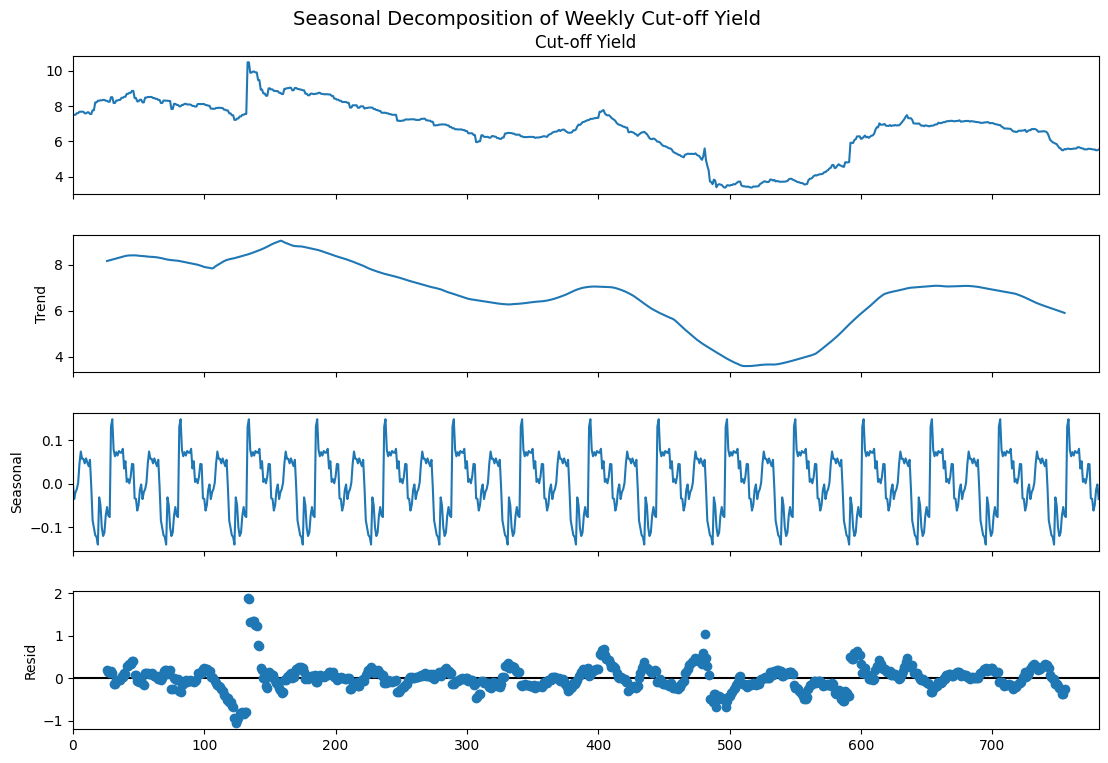

In [39]:
# Since data is weekly, and if you expect yearly seasonality, use period=52 (weeks in a year)
decomposition = seasonal_decompose(dfs['Cut-off Yield'], model='additive', period=52)

# --- STEP 3: Plot the components ---
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.suptitle('Seasonal Decomposition of Weekly Cut-off Yield', fontsize=14)
plt.show()

In [40]:
# --- STEP 4: Optional - Inspect individual components ---
df['trend'] = decomposition.trend
df['seasonal'] = decomposition.seasonal
df['resid'] = decomposition.resid

# To check if seasonality exists:
if df['seasonal'].abs().mean() > 0.01:  # threshold can vary
    print("✅ The data shows signs of seasonality.")
else:
    print("⚠️ No strong seasonality detected.")

✅ The data shows signs of seasonality.


### Performing Dickey-Fuller Test

To check data is stationary or non stationary

In [41]:
from statsmodels.tsa.stattools import adfuller

# Perform the ADF test
def adf_test(timeseries):
    # Perform Dickey-Fuller test:
    adf_result = adfuller(timeseries, autolag='AIC')
    
    # Print ADF test results
    print('ADF Statistic: {:.4f}'.format(adf_result[0]))
    print('p-value: {:.4f}'.format(adf_result[1]))
    print('Critical Values:')
    for key, value in adf_result[4].items():
        print('\t{}: {:.4f}'.format(key, value))

# Assuming 'Yield' column is the one you want to test for stationarity
adf_test(df['Cut-off Yield'])

ADF Statistic: -1.3343
p-value: 0.6133
Critical Values:
	1%: -3.4389
	5%: -2.8653
	10%: -2.5688


The p-value 0.6133 is greater than 0.05 for a significance level of 5%, indicating rejects the H1-(alternate hypothesis) and accepting the H0-(null hypothesis). Therefore, the data is likely non-stationary. it might require differencing or other transformations to achieve stationarity.

### AUTO ARIMA Forecasting

In [42]:
df.drop(['trend', 'seasonal', 'resid'], axis=1, inplace=True)
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df.set_index('Date', inplace=True)
df.head(3)

,Cut-off Price,Cut-off Yield,Fed_Reserve_Rate,Bank Rate,Repo,Reverse Repo,Standing Deposit Facility Rate,Marginal Standing Facility Rate,Cash Reserve Ratio,Statutory Liquidity Ratio,Net Liquidity,Overnight Repo Cut off,Overnight Rev Repo Cut off,Term Repo Cut off,Term Rev Repo Cut off,CPI Inflation,USDINR,foreign_exc_resrv,call_money_avg
Date,,,,,,,,,,,,,,,,,,,
2011-01-05,93.05,7.4896,0.5,6.0,6.25,5.25,3.75,8.25,6.0,24.0,1170340.0,8.01,7.99,8.8,7.99,89.5,45.20,13749360,6.58
2011-01-12,93.04,7.5012,0.5,6.0,6.25,5.25,3.75,8.25,6.0,24.0,856350.0,8.01,7.99,8.8,7.99,89.5,45.16,13749360,6.52
2011-01-19,93.04,7.5012,0.5,6.0,6.25,5.25,3.75,8.25,6.0,24.0,844000.0,8.01,7.99,8.8,7.99,89.5,45.38,13749360,6.23


In [43]:
# Step 2: Split Features
# --------------------------

target_col = 'Cut-off Yield'
exog_cols = [col for col in df.columns if col != target_col]

# Normalize exogenous variables
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[exog_cols] = scaler.fit_transform(df[exog_cols])
df_scaled.head(3)

,Cut-off Price,Cut-off Yield,Fed_Reserve_Rate,Bank Rate,Repo,Reverse Repo,Standing Deposit Facility Rate,Marginal Standing Facility Rate,Cash Reserve Ratio,Statutory Liquidity Ratio,Net Liquidity,Overnight Repo Cut off,Overnight Rev Repo Cut off,Term Repo Cut off,Term Rev Repo Cut off,CPI Inflation,USDINR,foreign_exc_resrv,call_money_avg
Date,,,,,,,,,,,,,,,,,,,
2011-01-05,-0.527206,7.4896,-0.84044,-0.465148,-0.07093,0.06992,-0.543637,0.831705,2.817949,1.7307,0.999066,1.440292,1.339216,1.443752,1.20018,-1.695415,-2.077357,-1.290752,0.249666
2011-01-12,-0.534783,7.5012,-0.84044,-0.465148,-0.07093,0.06992,-0.543637,0.831705,2.817949,1.7307,0.827956,1.440292,1.339216,1.443752,1.20018,-1.695415,-2.081012,-1.290752,0.210522
2011-01-19,-0.534783,7.5012,-0.84044,-0.465148,-0.07093,0.06992,-0.543637,0.831705,2.817949,1.7307,0.821226,1.440292,1.339216,1.443752,1.20018,-1.695415,-2.060911,-1.290752,0.021324


In [44]:
# Step 3: Auto ARIMA Model
# --------------------------
# Fit ARIMA with exogenous variables
arima_model = auto_arima(df_scaled[target_col],
                         exogenous=df_scaled[exog_cols],
                         seasonal=True,
                         stepwise=True,
                         suppress_warnings=True,
                         error_action='ignore',
                         trace=True,
                         m=52, d=1, test='adf', D=None) 

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[52] intercept   : AIC=inf, Time=27.46 sec
 ARIMA(0,1,0)(0,0,0)[52] intercept   : AIC=-796.996, Time=0.22 sec
 ARIMA(1,1,0)(1,0,0)[52] intercept   : AIC=-794.281, Time=5.42 sec
 ARIMA(0,1,1)(0,0,1)[52] intercept   : AIC=-794.466, Time=3.80 sec
 ARIMA(0,1,0)(0,0,0)[52]             : AIC=-798.763, Time=0.19 sec
 ARIMA(0,1,0)(1,0,0)[52] intercept   : AIC=-795.024, Time=6.65 sec
 ARIMA(0,1,0)(0,0,1)[52] intercept   : AIC=-795.019, Time=3.38 sec
 ARIMA(0,1,0)(1,0,1)[52] intercept   : AIC=inf, Time=6.32 sec
 ARIMA(1,1,0)(0,0,0)[52] intercept   : AIC=-796.251, Time=0.07 sec
 ARIMA(0,1,1)(0,0,0)[52] intercept   : AIC=-796.440, Time=0.44 sec
 ARIMA(1,1,1)(0,0,0)[52] intercept   : AIC=-805.142, Time=0.38 sec
 ARIMA(1,1,1)(1,0,0)[52] intercept   : AIC=-803.174, Time=7.29 sec
 ARIMA(1,1,1)(0,0,1)[52] intercept   : AIC=-803.169, Time=8.12 sec
 ARIMA(1,1,1)(1,0,1)[52] intercept   : AIC=inf, Time=15.18 sec
 ARIMA(2,1,1)(0,0,0)[52] interce

### XGBoost Regressor

In [45]:
# # --------------------------
# # Step 4: Train XGBoost on historical data with RandomsearchCV
# # --------------------------

# Base model and pipeline (no scaler here since df_scaled is already normalized)
xgb_base = XGBRegressor(
    objective='reg:squarederror',
    random_state=42
)
xgb_pipe = Pipeline([
    ('model', xgb_base)
])

# Sensible search space (adjust ranges if your series is large/complex)
param_distributions = {
    'model__n_estimators':     [400, 800, 1200, 2000],
    'model__learning_rate':    [0.01, 0.03, 0.05, 0.1],
    'model__max_depth':        [3, 4, 5, 6, 8],
    'model__min_child_weight': [1, 3, 5, 7],
    'model__subsample':        [0.6, 0.75, 0.85, 1.0],
    'model__colsample_bytree': [0.6, 0.75, 0.85, 1.0],
    'model__gamma':            [0, 0.1, 0.3, 0.5],
    'model__reg_alpha':        [0.0, 0.001, 0.01, 0.1],
    'model__reg_lambda':       [0.5, 1.0, 2.0, 5.0],
    # If GPU is available: add 'model__tree_method': ['gpu_hist']
}

# Time-series CV to preserve order (no leakage)
tscv = TimeSeriesSplit(n_splits=5)

# Randomized search (fast + broad); scoring uses RMSE
search = RandomizedSearchCV(
    estimator=xgb_pipe,
    param_distributions=param_distributions,
    n_iter=40,  # increase to 80-100 for deeper search
    scoring='neg_root_mean_squared_error',
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

X= df_scaled[exog_cols]
y= df_scaled[target_col]

# Run tuning
search.fit(X, y)

# Results
print("Best params:", search.best_params_)
print("Best CV RMSE:", search.best_score_)

# Fitted pipeline you can use downstream
xgb_pipe = search.best_estimator_


Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best params: {'model__subsample': 0.85, 'model__reg_lambda': 2.0, 'model__reg_alpha': 0.01, 'model__n_estimators': 800, 'model__min_child_weight': 1, 'model__max_depth': 6, 'model__learning_rate': 0.05, 'model__gamma': 0, 'model__colsample_bytree': 1.0}
Best CV RMSE: -0.5051317964077336


In [46]:
# # --------------------------
# # Step 4: Train XGBoost on historical data
# # --------------------------

# xgb_model = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=4,
#                          subsample=0.8, colsample_bytree=0.8, random_state=42)
# xgb_model.fit(df_scaled[exog_cols], df_scaled[target_col])

#yhat_future_xgb = xgb_pipe.predict(df_exog_future_scaled)


### Forecast each exogenous series for next N steps

In [47]:
# --------------------------
# Step 5: Forecast macro economic factor for next 5 weeks
# --------------------------

future_steps = 5

def forecast_exog_series(series: pd.Series, n_steps: int):
    """
    Forecast a single exogenous time series using auto_arima.
    If the series is constant or fails to fit, carry-forward the last value.
    """
    series = series.astype(float)
    if series.std(ddof=1) < 1e-8:  # practically constant
        return np.repeat(series.iloc[-1], n_steps)

    try:
        model = auto_arima(
            series,
            seasonal=True,
            stepwise=True,
            suppress_warnings=True,
            error_action='ignore',
            trace=False
        )
        fc = model.predict(n_periods=n_steps)
        return np.asarray(fc)
    except Exception:
        # Fallback: carry forward last value
        return np.repeat(series.iloc[-1], n_steps)

# Build future index based on typical cadence
date_diffs = df.index.to_series().diff().dropna()
typical_gap = date_diffs.median() if len(date_diffs) > 0 else pd.Timedelta(days=7)
last_date = df.index[-1]
future_idx = pd.Index([last_date + typical_gap * (i+1) for i in range(future_steps)], name='Date')

# Forecast all exogenous variables (in original scale)
exog_future_raw = {}
for col in exog_cols:
    exog_future_raw[col] = forecast_exog_series(df[col], future_steps)

df_exog_future_raw = pd.DataFrame(exog_future_raw, index=future_idx)

In [48]:
# Forecasted macro economic factors
df_exog_future_raw.head()

,Cut-off Price,Fed_Reserve_Rate,Bank Rate,Repo,Reverse Repo,Standing Deposit Facility Rate,Marginal Standing Facility Rate,Cash Reserve Ratio,Statutory Liquidity Ratio,Net Liquidity,Overnight Repo Cut off,Overnight Rev Repo Cut off,Term Repo Cut off,Term Rev Repo Cut off,CPI Inflation,USDINR,foreign_exc_resrv,call_money_avg
Date,,,,,,,,,,,,,,,,,,
2025-12-31,94.764655,3.75,5.75,5.5,3.35,5.25,5.75,2.996159,18.0,-1.461657e+06,5.280420,5.49,5.269036,5.24,197.954968,89.827368,6.265101e+07,5.370607
2026-01-07,94.765622,3.75,5.75,5.5,3.35,5.25,5.75,2.992318,18.0,-1.566046e+06,5.276924,5.49,5.274734,5.24,198.019461,89.884436,6.271355e+07,5.354956
2026-01-14,94.764780,3.75,5.75,5.5,3.35,5.25,5.75,2.988476,18.0,-1.807324e+06,5.273428,5.49,5.289527,5.24,198.111926,89.941505,6.277608e+07,5.291263
2026-01-21,94.765513,3.75,5.75,5.5,3.35,5.25,5.75,2.984635,18.0,-1.358793e+06,5.269932,5.49,5.277571,5.24,198.228683,89.998573,6.283862e+07,5.315652
2026-01-28,94.764876,3.75,5.75,5.5,3.35,5.25,5.75,2.980794,18.0,-1.367758e+06,5.266437,5.49,5.281477,5.24,198.375074,90.055641,6.290115e+07,5.361512


In [49]:
# ------------------------------
# Step:6 Scale future exogenous with the same scaler
# ------------------------------

exog_future_scaled = scaler.transform(df_exog_future_raw[exog_cols])
df_exog_future_scaled = pd.DataFrame(exog_future_scaled, index=future_idx, columns=exog_cols)
df_exog_future_scaled.head(3)


,Cut-off Price,Fed_Reserve_Rate,Bank Rate,Repo,Reverse Repo,Standing Deposit Facility Rate,Marginal Standing Facility Rate,Cash Reserve Ratio,Statutory Liquidity Ratio,Net Liquidity,Overnight Repo Cut off,Overnight Rev Repo Cut off,Term Repo Cut off,Term Rev Repo Cut off,CPI Inflation,USDINR,foreign_exc_resrv,call_money_avg
Date,,,,,,,,,,,,,,,,,,
2025-12-31,0.771933,1.034458,-0.629679,-0.663524,-1.197762,1.047992,-0.725675,-1.863362,-0.975664,-0.435251,-1.557669,-0.8067,-0.865969,-0.883715,1.752078,2.000180,2.066150,-0.539349
2026-01-07,0.772666,1.034458,-0.629679,-0.663524,-1.197762,1.047992,-0.725675,-1.869348,-0.975664,-0.492138,-1.561509,-0.8067,-0.862241,-0.883715,1.754128,2.005394,2.070443,-0.549560
2026-01-14,0.772028,1.034458,-0.629679,-0.663524,-1.197762,1.047992,-0.725675,-1.875334,-0.975664,-0.623624,-1.565348,-0.8067,-0.852564,-0.883715,1.757068,2.010608,2.074736,-0.591113


### Hybrid Forecast (ARIMA & XGBoost) for Next 5 Instances

In [50]:
# ------------------------------
# step:7 Forecast Cut-off Yield for each future weeks (ARIMA-model & XGBoost model)
# ------------------------------
arima_preds = []
xgb_preds = []
hybrid_preds = []

future_steps = 5

# Option A: one-step-at-a-time (keeps ARIMA model fixed)
# for i in range(future_steps):
#     x_row = df_exog_future_scaled.iloc[i].values.reshape(1, -1)

#     # ARIMA-X forecast using future exog
#     arima_yhat = arima_model.predict(n_periods=1, exogenous=x_row)[0]
#     arima_preds.append(arima_yhat)

#     # XGB forecast using future exog
#     xgb_yhat = xgb_model.predict(x_row)[0]
#     xgb_preds.append(xgb_yhat)

#     # Hybrid
#     hybrid_preds.append((arima_yhat + xgb_yhat) / 2.0)

# Optional: Option B (recursive update) – comment out Option A loop above and use this block instead.
# It updates ARIMA with its own predicted y at each step. Use carefully.
#current_arima = arima_model.copy()
for i in range(future_steps):
    x_row = df_exog_future_scaled.iloc[i].values.reshape(1, -1)
    arima_yhat = arima_model.predict(n_periods=1, exogenous=x_row)[0]
    arima_preds.append(arima_yhat)
    xgb_yhat = xgb_pipe.predict(x_row)[0]
    xgb_preds.append(xgb_yhat)
    hybrid_yhat = (arima_yhat + xgb_yhat) / 2.0
    hybrid_preds.append(hybrid_yhat)
    # Update ARIMA state with predicted y (approximate; requires caution)
    try:
        arima_model.update(pd.Series([hybrid_yhat]), exogenous=x_row)
    except Exception:
        pass

In [51]:
# ------------------------------
# Step:8 Forecasted results
# ------------------------------

forecast_df = pd.DataFrame({
    'ARIMA_X_Pred': arima_preds,
    'XGB_Pred': xgb_preds,
    'Hybrid_Pred': hybrid_preds
}, index=future_idx)

print("\n=== 5-week Forecasts ===")
print(forecast_df.round(4))


=== 5-week Forecasts ===
            ARIMA_X_Pred  XGB_Pred  Hybrid_Pred
Date                                           
2025-12-31        5.5402    5.5428       5.5415
2026-01-07        5.5403    5.5428       5.5415
2026-01-14        5.5427    5.5373       5.5400
2026-01-21        5.5388    5.5427       5.5407
2026-01-28        5.5419    5.5422       5.5420


### -------- Forecasting End -----------

In [52]:
# If you also want to extend the original df with forecasts:
df_future_full = pd.concat([
    df_scaled,  # historical scaled
    pd.DataFrame(
        # attach hybrid target into a new block with scaled exog
        data=np.column_stack([df_exog_future_scaled.values, np.array(hybrid_preds)]),
        index=future_idx,
        columns=[*exog_cols, target_col]
    )
], axis=0)
df_future_full.tail(8)

,Cut-off Price,Cut-off Yield,Fed_Reserve_Rate,Bank Rate,Repo,Reverse Repo,Standing Deposit Facility Rate,Marginal Standing Facility Rate,Cash Reserve Ratio,Statutory Liquidity Ratio,Net Liquidity,Overnight Repo Cut off,Overnight Rev Repo Cut off,Term Repo Cut off,Term Rev Repo Cut off,CPI Inflation,USDINR,foreign_exc_resrv,call_money_avg
Date,,,,,,,,,,,,,,,,,,,
2025-12-10,0.802350,5.494900,1.034458,-0.629679,-0.663524,-1.197762,1.047992,-0.725675,-1.857375,-0.975664,-0.344909,-1.305516,-0.8067,-0.708346,-0.883715,1.750331,2.005190,2.061858,-0.533221
2025-12-17,0.795910,5.504400,1.034458,-0.629679,-0.663524,-1.197762,1.047992,-0.725675,-1.857375,-0.975664,-0.802378,-1.305516,-0.8067,-0.708346,-0.883715,1.750331,2.046022,2.061858,-0.657178
2025-12-24,0.772649,5.538700,1.034458,-0.629679,-0.663524,-1.197762,1.047992,-0.725675,-1.857375,-0.975664,-0.265364,-1.580096,-0.8067,-0.871879,-0.883715,1.750331,1.994966,2.061858,-0.546269
2025-12-31,0.771933,5.541497,1.034458,-0.629679,-0.663524,-1.197762,1.047992,-0.725675,-1.863362,-0.975664,-0.435251,-1.557669,-0.8067,-0.865969,-0.883715,1.752078,2.000180,2.066150,-0.539349
2026-01-07,0.772666,5.541539,1.034458,-0.629679,-0.663524,-1.197762,1.047992,-0.725675,-1.869348,-0.975664,-0.492138,-1.561509,-0.8067,-0.862241,-0.883715,1.754128,2.005394,2.070443,-0.549560
2026-01-14,0.772028,5.539977,1.034458,-0.629679,-0.663524,-1.197762,1.047992,-0.725675,-1.875334,-0.975664,-0.623624,-1.565348,-0.8067,-0.852564,-0.883715,1.757068,2.010608,2.074736,-0.591113
2026-01-21,0.772583,5.540748,1.034458,-0.629679,-0.663524,-1.197762,1.047992,-0.725675,-1.881321,-0.975664,-0.379195,-1.569187,-0.8067,-0.860385,-0.883715,1.760779,2.015822,2.079028,-0.575202
2026-01-28,0.772100,5.542046,1.034458,-0.629679,-0.663524,-1.197762,1.047992,-0.725675,-1.887307,-0.975664,-0.384080,-1.573027,-0.8067,-0.857830,-0.883715,1.765432,2.021037,2.083321,-0.545282


In [ ]:
# Optional: save forecasts
# forecast_df= df_future_full.tail(future_steps)
# forecast_df.to_csv(r"D:\TASK\CP rates\Hybrid model\364days_tbill_hybrid_5week_fc.csv")

### Visualize Forecast

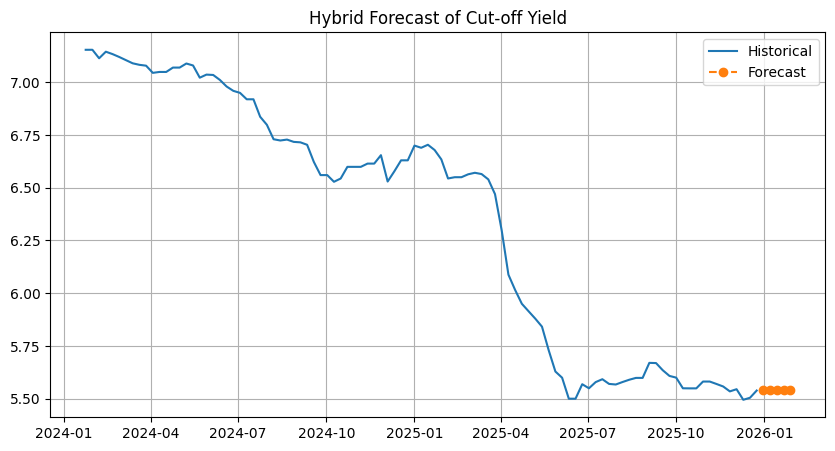

In [53]:
dfrsv=df.iloc[-101:,:] # Selecting last 2 years data to visualize

# Creating dataframe for forecasted values
df_forecast= df_future_full.tail(future_steps)

# Plot
plt.figure(figsize=(10, 5))
plt.plot(dfrsv.index, dfrsv[target_col], label='Historical')
plt.plot(df_forecast.index, df_forecast[target_col], label='Forecast', linestyle='--', marker='o')
plt.title('Hybrid Forecast of Cut-off Yield')
plt.legend()
plt.grid(True)
plt.show()